# MATH 5010 Computer Lab — Section 5: Transformations of Random Variables

**Instructor version with full solutions**

This lab supports Section 5: **Transformations**.  The goal is to connect the symbolic formulas from lecture with computational experiments in Python.

## Learning goals

By the end of this lab, you should be able to:

1. Transform discrete random variables by collecting probabilities over inverse images.
2. Use the CDF method for continuous transformations.
3. Apply the monotone and non-monotone transformation formulas.
4. Use inverse-transform sampling.
5. Use Jacobians for transformations of two or more variables.
6. Compute and simulate convolutions, products, quotients, maxima, and minima.
7. Check formulas by simulation and visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi, exp, log

rng = np.random.default_rng(5010)

# Helper functions

def normal_pdf(x, mu=0.0, sigma=1.0):
    x = np.asarray(x)
    return (1 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

def exp_pdf(x, lam=1.0):
    x = np.asarray(x)
    return lam * np.exp(-lam*x) * (x >= 0)

def empirical_prob(condition):
    return np.mean(condition)

print("Libraries loaded.")

Libraries loaded.


## 1. Discrete transformation: collect probabilities over inverse images

If $X$ is discrete and $Y=g(X)$, then

$$
P(Y=y)=\sum_{x:g(x)=y} P(X=x).
$$

This is the discrete version of the idea that we must collect all original values of $X$ that map to the same value of $Y$.

### Example 1
Let $X$ be uniform on the set $\{-2,-1,0,1,2\}$ and let

$$
Y = 2|X|.
$$

Find the pmf of $Y$.

In [2]:
# Solution to Example 1
x_values = np.array([-2, -1, 0, 1, 2])
px = np.ones_like(x_values, dtype=float) / len(x_values)
y_values = 2 * np.abs(x_values)

pmf_y = {}
for x, p, y in zip(x_values, px, y_values):
    pmf_y[y] = pmf_y.get(y, 0) + p

print("PMF of Y = 2|X|:")
for y in sorted(pmf_y):
    print(f"P(Y={y}) = {pmf_y[y]:.3f}")

# Check total probability
print("Total probability:", sum(pmf_y.values()))

PMF of Y = 2|X|:
P(Y=0) = 0.200
P(Y=2) = 0.400
P(Y=4) = 0.400
Total probability: 1.0


**Interpretation.** The possible values are $Y=0,2,4$. We have

$$
P(Y=0)=P(X=0)=\frac15,
$$

$$
P(Y=2)=P(X=-1)+P(X=1)=\frac25,
$$

and

$$
P(Y=4)=P(X=-2)+P(X=2)=\frac25.
$$

### Practice 1
Let $X$ have pmf

$$
P(X=-2)=0.1,\quad P(X=-1)=0.2,\quad P(X=0)=0.4,\quad P(X=1)=0.2,\quad P(X=2)=0.1.
$$

Let $Y=X^2$. Find the pmf of $Y$.

In [3]:
# Solution to Practice 1
x_values = np.array([-2, -1, 0, 1, 2])
px = np.array([0.1, 0.2, 0.4, 0.2, 0.1])
y_values = x_values**2

pmf_y = {}
for x, p, y in zip(x_values, px, y_values):
    pmf_y[y] = pmf_y.get(y, 0) + p

print("PMF of Y = X^2:")
for y in sorted(pmf_y):
    print(f"P(Y={y}) = {pmf_y[y]:.3f}")

assert np.isclose(sum(pmf_y.values()), 1)

PMF of Y = X^2:
P(Y=0) = 0.400
P(Y=1) = 0.400
P(Y=4) = 0.200


**Solution.** The possible values are $0,1,4$. Therefore

$$
P(Y=0)=P(X=0)=0.4,
$$

$$
P(Y=1)=P(X=-1)+P(X=1)=0.2+0.2=0.4,
$$

and

$$
P(Y=4)=P(X=-2)+P(X=2)=0.1+0.1=0.2.
$$

## 2. Continuous transformation by the CDF method

For a continuous random variable $X$ and transformation $Y=g(X)$, the CDF method is often the safest starting point:

$$
F_Y(y)=P(Y\le y)=P(g(X)\le y).
$$

Then the pdf is obtained by differentiating $F_Y(y)$ where differentiable.

### Example 2
Let $X\sim \operatorname{Uniform}(0,1)$ and let $Y=X^2$. Find $F_Y(y)$ and $f_Y(y)$.

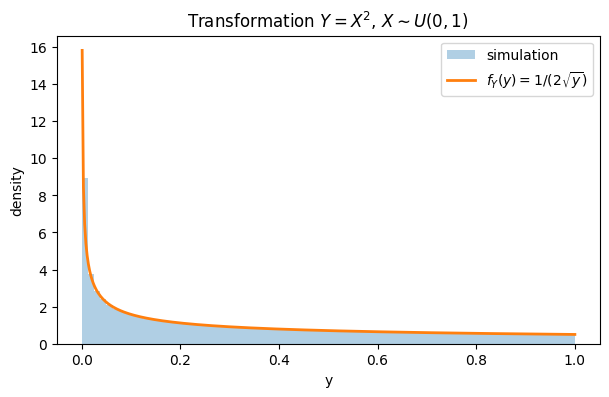

y=0.04: empirical CDF=0.2001, theoretical CDF=0.2000
y=0.25: empirical CDF=0.4993, theoretical CDF=0.5000
y=0.64: empirical CDF=0.7993, theoretical CDF=0.8000


In [4]:
# Solution to Example 2: simulation check
N = 200_000
X = rng.uniform(0, 1, N)
Y = X**2

ys = np.linspace(0.001, 1, 400)
theory_pdf = 1 / (2*np.sqrt(ys))

plt.figure(figsize=(7, 4))
plt.hist(Y, bins=80, density=True, alpha=0.35, label="simulation")
plt.plot(ys, theory_pdf, linewidth=2, label=r"$f_Y(y)=1/(2\sqrt{y})$")
plt.xlabel("y")
plt.ylabel("density")
plt.title(r"Transformation $Y=X^2$, $X\sim U(0,1)$")
plt.legend()
plt.show()

# numerical CDF check at y = 0.25
for y0 in [0.04, 0.25, 0.64]:
    empirical = np.mean(Y <= y0)
    theoretical = np.sqrt(y0)
    print(f"y={y0:.2f}: empirical CDF={empirical:.4f}, theoretical CDF={theoretical:.4f}")

**Solution.** For $0<y<1$,

$$
F_Y(y)=P(Y\le y)=P(X^2\le y)=P(X\le \sqrt{y})=\sqrt{y}.
$$

Thus

$$
F_Y(y)=
\begin{cases}
0, & y<0,\\
\sqrt{y}, & 0\le y\le 1,\\
1, & y>1.
\end{cases}
$$

Differentiating on $(0,1)$ gives

$$
f_Y(y)=\frac{1}{2\sqrt{y}},\qquad 0<y<1.
$$

### Practice 2
Let $X\sim\operatorname{Uniform}(-1,1)$ and $Y=X^2$. Find the pdf of $Y$ and verify by simulation.

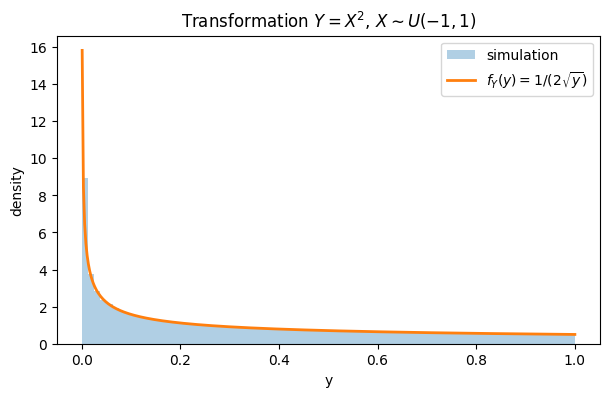

The same density appears because both inverse branches contribute.


In [5]:
# Solution to Practice 2
N = 200_000
X = rng.uniform(-1, 1, N)
Y = X**2

ys = np.linspace(0.001, 1, 400)
theory_pdf = 1 / (2*np.sqrt(ys))

plt.figure(figsize=(7, 4))
plt.hist(Y, bins=80, density=True, alpha=0.35, label="simulation")
plt.plot(ys, theory_pdf, linewidth=2, label=r"$f_Y(y)=1/(2\sqrt{y})$")
plt.xlabel("y")
plt.ylabel("density")
plt.title(r"Transformation $Y=X^2$, $X\sim U(-1,1)$")
plt.legend()
plt.show()

print("The same density appears because both inverse branches contribute.")

**Solution.** For $0<y<1$,

$$
F_Y(y)=P(X^2\le y)=P(-\sqrt y\le X\le \sqrt y).
$$

Because $X\sim U(-1,1)$ has density $1/2$,

$$
F_Y(y)=\frac{2\sqrt y}{2}=\sqrt y.
$$

Therefore

$$
f_Y(y)=\frac{1}{2\sqrt y},\qquad 0<y<1.
$$

## 3. Monotone transformation formula

If $Y=g(X)$ and $g$ is one-to-one and differentiable, with inverse $x=g^{-1}(y)$, then

$$
f_Y(y)=f_X(g^{-1}(y))\left|\frac{d}{dy}g^{-1}(y)\right|.
$$

### Example 3: Lognormal distribution
Let $Z\sim N(0,1)$ and let $X=e^Z$. Then $X$ is lognormal. Since $z=\log x$,

$$
f_X(x)=\frac{1}{x\sqrt{2\pi}}\exp\left[-\frac{(\log x)^2}{2}\right],\qquad x>0.
$$

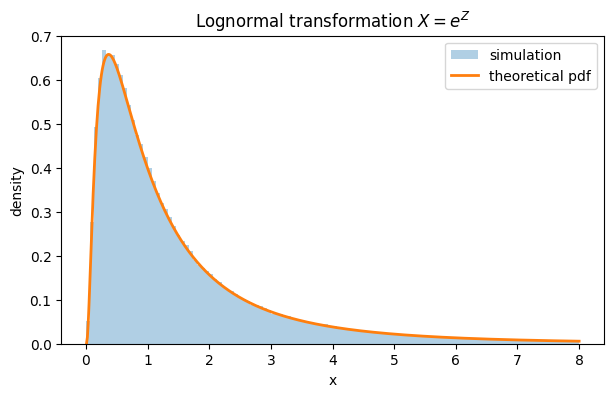

Sample mean: 1.6514486530104664
Theoretical mean e^(1/2): 1.6487212707001282


In [6]:
# Solution to Example 3: simulate standard lognormal and compare with pdf
N = 200_000
Z = rng.normal(0, 1, N)
X = np.exp(Z)

xs = np.linspace(0.01, 8, 600)
lognormal_pdf = (1 / (xs * np.sqrt(2*np.pi))) * np.exp(-0.5 * (np.log(xs))**2)

plt.figure(figsize=(7, 4))
plt.hist(X, bins=120, density=True, alpha=0.35, range=(0, 8), label="simulation")
plt.plot(xs, lognormal_pdf, linewidth=2, label="theoretical pdf")
plt.xlabel("x")
plt.ylabel("density")
plt.title(r"Lognormal transformation $X=e^Z$")
plt.legend()
plt.show()

print("Sample mean:", X.mean())
print("Theoretical mean e^(1/2):", np.exp(0.5))

### Practice 3
Let $X\sim \operatorname{Exponential}(\lambda)$ and let $Y=aX+b$ where $a>0$. Find the pdf of $Y$.

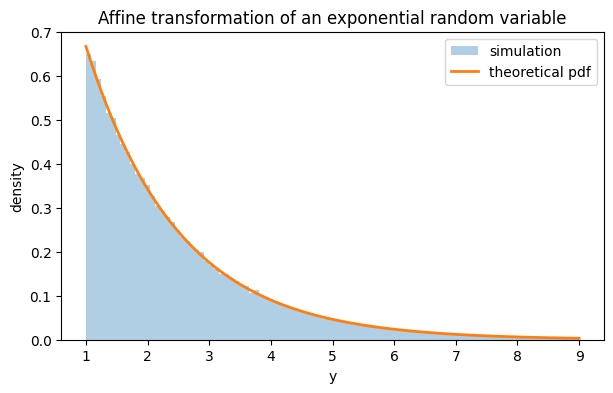

In [7]:
# Solution to Practice 3: simulate and compare
lam = 2.0
aval = 3.0
bval = 1.0
N = 200_000
X = rng.exponential(scale=1/lam, size=N)
Y = aval*X + bval

ys = np.linspace(bval, bval + 8, 500)
theory_pdf = (lam/aval) * np.exp(-lam*(ys-bval)/aval)

plt.figure(figsize=(7, 4))
plt.hist(Y, bins=100, density=True, alpha=0.35, range=(bval, bval+8), label="simulation")
plt.plot(ys, theory_pdf, linewidth=2, label="theoretical pdf")
plt.xlabel("y")
plt.ylabel("density")
plt.title(r"Affine transformation of an exponential random variable")
plt.legend()
plt.show()

**Solution.** Since $Y=aX+b$, the inverse is

$$
x=\frac{y-b}{a}.
$$

Because $X>0$, the support is $y>b$. The derivative of the inverse is $1/a$. Therefore

$$
f_Y(y)=f_X\left(\frac{y-b}{a}\right)\frac{1}{a}
=\frac{\lambda}{a}\exp\left[-\lambda\frac{y-b}{a}\right],\qquad y>b.
$$

## 4. Inverse-transform sampling

If $U\sim U(0,1)$ and $F$ is a continuous CDF, then

$$
X = F^{-1}(U)
$$

has CDF $F$. This is called **inverse-transform sampling**.

### Example 4: Exponential sampling
For $X\sim \operatorname{Exponential}(\lambda)$,

$$
F(x)=1-e^{-\lambda x},\qquad x\ge 0.
$$

Solving $u=1-e^{-\lambda x}$ gives

$$
x=-\frac{1}{\lambda}\log(1-u).
$$

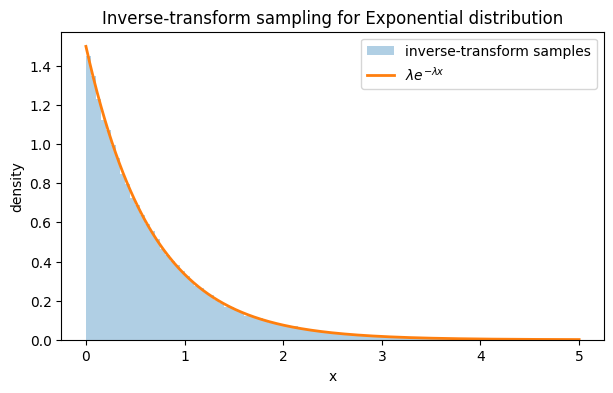

Sample mean: 0.6673750644867305
Theoretical mean: 0.6666666666666666


In [8]:
# Solution to Example 4
lam = 1.5
N = 200_000
U = rng.uniform(0, 1, N)
X_inverse = -np.log(1-U) / lam

xs = np.linspace(0, 5, 400)
theory = exp_pdf(xs, lam=lam)

plt.figure(figsize=(7, 4))
plt.hist(X_inverse, bins=100, density=True, alpha=0.35, range=(0, 5), label="inverse-transform samples")
plt.plot(xs, theory, linewidth=2, label=r"$\lambda e^{-\lambda x}$")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Inverse-transform sampling for Exponential distribution")
plt.legend()
plt.show()

print("Sample mean:", X_inverse.mean())
print("Theoretical mean:", 1/lam)

### Practice 4
Use inverse-transform sampling to generate a Cauchy random variable with location $x_0=0$ and scale $\gamma=1$. The CDF is

$$
F(x)=\frac{1}{\pi}\tan^{-1}(x)+\frac12.
$$

Find $F^{-1}(u)$ and simulate from the distribution.

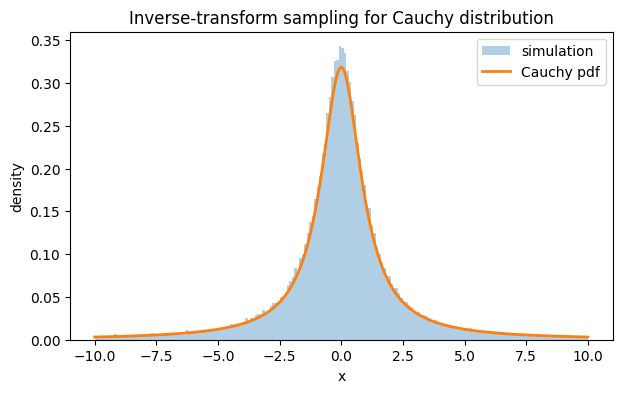

Sample median is stable: -0.00862792109937964
Sample mean is unstable for Cauchy: 0.21422069857582188


In [9]:
# Solution to Practice 4
N = 100_000
U = rng.uniform(0, 1, N)
X_cauchy = np.tan(np.pi*(U - 0.5))

xs = np.linspace(-10, 10, 1000)
cauchy_pdf = 1 / (np.pi * (1 + xs**2))

plt.figure(figsize=(7, 4))
plt.hist(X_cauchy, bins=200, density=True, alpha=0.35, range=(-10, 10), label="simulation")
plt.plot(xs, cauchy_pdf, linewidth=2, label="Cauchy pdf")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Inverse-transform sampling for Cauchy distribution")
plt.legend()
plt.show()

print("Sample median is stable:", np.median(X_cauchy))
print("Sample mean is unstable for Cauchy:", np.mean(X_cauchy))

**Solution.** We solve

$$
u=\frac{1}{\pi}\tan^{-1}(x)+\frac12.
$$

Thus

$$
\tan^{-1}(x)=\pi\left(u-\frac12\right),
$$

so

$$
F^{-1}(u)=\tan\left(\pi\left(u-\frac12\right)\right).
$$

Therefore, if $U\sim U(0,1)$, then

$$
X=\tan\left(\pi(U-1/2)\right)
$$

has the standard Cauchy distribution.

## 5. Transformations of two variables and Jacobians

Suppose $(X_1,X_2)$ has joint pdf $f_X(x_1,x_2)$ and

$$
Y_1=g_1(X_1,X_2),\qquad Y_2=g_2(X_1,X_2).
$$

If the inverse transformation is

$$
X_1=h_1(Y_1,Y_2),\qquad X_2=h_2(Y_1,Y_2),
$$

then

$$
f_Y(y_1,y_2)=f_X(h_1(y_1,y_2),h_2(y_1,y_2))
\left|\frac{\partial(x_1,x_2)}{\partial(y_1,y_2)}\right|.
$$

### Example 5: Sum and one original variable
Let $X,Y$ be independent Exponential$(1)$ variables. Define

$$
S=X+Y,\qquad W=X.
$$

Find the joint density of $(S,W)$ and the marginal density of $S$.

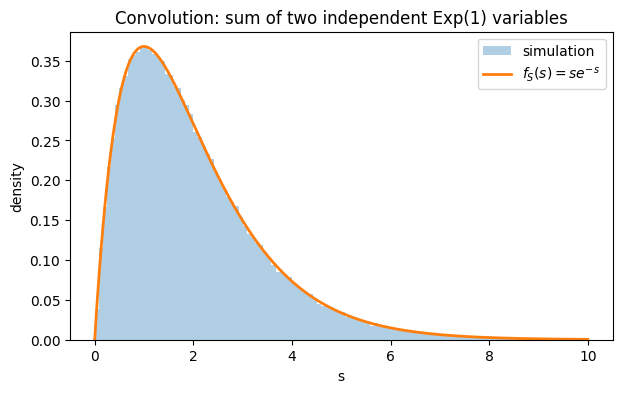

Empirical mean of S: 1.9977127873614668
Theoretical mean of S: 2


In [10]:
# Solution to Example 5: simulate S = X + Y and compare with Gamma(2, rate=1) pdf
N = 200_000
X = rng.exponential(scale=1, size=N)
Y = rng.exponential(scale=1, size=N)
S = X + Y

ss = np.linspace(0, 10, 500)
# Gamma(shape=2, rate=1): f(s) = s e^{-s}, s>0
fS = ss * np.exp(-ss)

plt.figure(figsize=(7, 4))
plt.hist(S, bins=120, density=True, alpha=0.35, range=(0, 10), label="simulation")
plt.plot(ss, fS, linewidth=2, label=r"$f_S(s)=s e^{-s}$")
plt.xlabel("s")
plt.ylabel("density")
plt.title(r"Convolution: sum of two independent Exp(1) variables")
plt.legend()
plt.show()

print("Empirical mean of S:", S.mean())
print("Theoretical mean of S:", 2)

**Solution.** The inverse transformation is

$$
X=W,\qquad Y=S-W.
$$

The Jacobian determinant has absolute value $1$. Since $X>0$ and $Y>0$, we need

$$
0<w<s.
$$

Thus

$$
f_{S,W}(s,w)=e^{-w}e^{-(s-w)}=e^{-s},\qquad 0<w<s.
$$

The marginal pdf of $S$ is

$$
f_S(s)=\int_0^s e^{-s}\,dw=se^{-s},\qquad s>0.
$$

So $S\sim \operatorname{Gamma}(2,1)$ using the shape-rate convention.

### Practice 5
Let $X,Y$ be independent $U(0,1)$ random variables. Use simulation to study the distribution of

$$
S=X+Y.
$$

The theoretical pdf is triangular:

$$
f_S(s)=
\begin{cases}
s, & 0<s<1,\\
2-s, & 1\le s<2,\\
0, & \text{otherwise}.
\end{cases}
$$

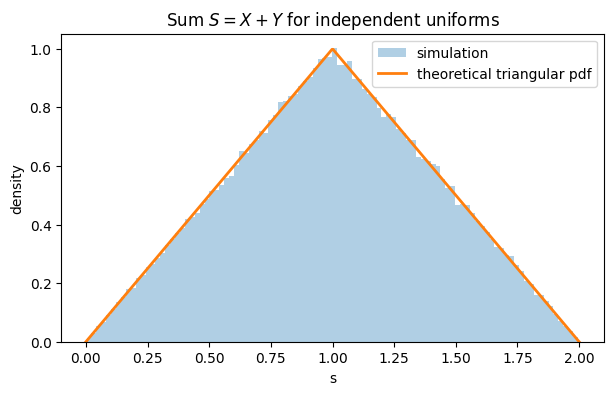

In [11]:
# Solution to Practice 5
N = 200_000
X = rng.uniform(0, 1, N)
Y = rng.uniform(0, 1, N)
S = X + Y

ss = np.linspace(0, 2, 500)
tri_pdf = np.where(ss < 1, ss, 2 - ss)

plt.figure(figsize=(7, 4))
plt.hist(S, bins=100, density=True, alpha=0.35, label="simulation")
plt.plot(ss, tri_pdf, linewidth=2, label="theoretical triangular pdf")
plt.xlabel("s")
plt.ylabel("density")
plt.title(r"Sum $S=X+Y$ for independent uniforms")
plt.legend()
plt.show()

**Solution.** The convolution formula gives

$$
f_S(s)=\int_{-\infty}^{\infty} f_X(x)f_Y(s-x)\,dx.
$$

Since both densities equal $1$ on $(0,1)$, the integrand is $1$ when

$$
0<x<1 \quad \text{and}\quad 0<s-x<1.
$$

That means

$$
\max(0,s-1)<x<\min(1,s).
$$

The length of this interval is $s$ for $0<s<1$ and $2-s$ for $1<s<2$.

## 6. Polar transformation and Box--Muller normal simulation

Let $Z_1,Z_2$ be independent standard normal variables. In polar coordinates,

$$
Z_1=R\cos\Theta,\qquad Z_2=R\sin\Theta.
$$

The Jacobian contributes a factor $R$. The joint density becomes

$$
f_{R,\Theta}(r,\theta)=\frac{1}{2\pi}e^{-r^2/2}r,
\qquad r>0,\quad 0<\theta<2\pi.
$$

Thus $\Theta\sim U(0,2\pi)$ and $R$ has CDF

$$
F_R(r)=1-e^{-r^2/2}.
$$

Solving $U=1-e^{-r^2/2}$ gives

$$
R=\sqrt{-2\log(1-U)}.
$$

This yields the Box--Muller method.

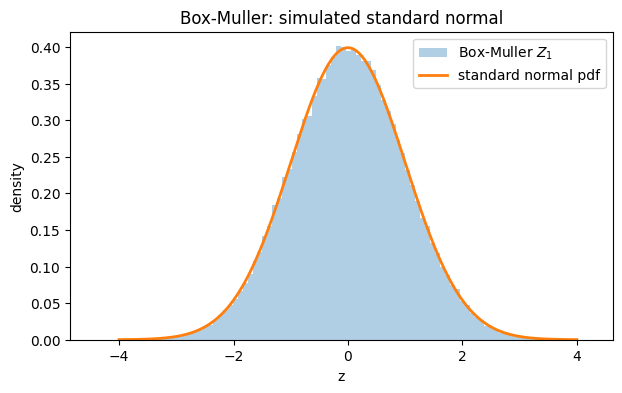

Mean of Z1: -3.1066987792828866e-05
Variance of Z1: 0.9963666580231078
Correlation of Z1 and Z2: 0.001181899238054314


In [12]:
# Solution: Box-Muller simulation
N = 200_000
U1 = rng.uniform(0, 1, N)
U2 = rng.uniform(0, 1, N)
R = np.sqrt(-2*np.log(1-U1))
Theta = 2*np.pi*U2
Z1 = R*np.cos(Theta)
Z2 = R*np.sin(Theta)

xs = np.linspace(-4, 4, 500)

plt.figure(figsize=(7, 4))
plt.hist(Z1, bins=100, density=True, alpha=0.35, label="Box-Muller $Z_1$")
plt.plot(xs, normal_pdf(xs), linewidth=2, label="standard normal pdf")
plt.xlabel("z")
plt.ylabel("density")
plt.title("Box-Muller: simulated standard normal")
plt.legend()
plt.show()

print("Mean of Z1:", Z1.mean())
print("Variance of Z1:", Z1.var())
print("Correlation of Z1 and Z2:", np.corrcoef(Z1, Z2)[0,1])

## 7. Quotients and products

For independent continuous random variables $X,Y$, formulas for quotients and products can be derived using a two-variable transformation.

### Product example
Let $X,Y\sim U(0,1)$ independent and let

$$
W=XY.
$$

For $0<w<1$,

$$
F_W(w)=P(XY\le w)=w(1-\log w),
$$

so

$$
f_W(w)=-\log w,\qquad 0<w<1.
$$

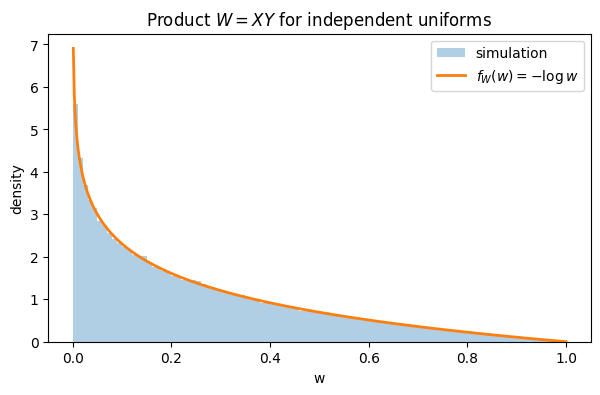

In [13]:
# Product simulation
N = 200_000
X = rng.uniform(0, 1, N)
Y = rng.uniform(0, 1, N)
W = X*Y

ws = np.linspace(0.001, 1, 500)
fW = -np.log(ws)

plt.figure(figsize=(7, 4))
plt.hist(W, bins=100, density=True, alpha=0.35, label="simulation")
plt.plot(ws, fW, linewidth=2, label=r"$f_W(w)=-\log w$")
plt.xlabel("w")
plt.ylabel("density")
plt.title(r"Product $W=XY$ for independent uniforms")
plt.legend()
plt.show()

### Practice 6
Let $X,Y\sim U(0,1)$ independent and let

$$
Q=\frac{X}{Y}.
$$

Show that

$$
F_Q(q)=
\begin{cases}
0, & q\le 0,\\
q/2, & 0<q<1,\\
1-\frac{1}{2q}, & q\ge 1.
\end{cases}
$$

Verify the formula by simulation.

q=0.25: empirical=0.1249, theoretical=0.1250
q= 0.5: empirical=0.2493, theoretical=0.2500
q= 1.0: empirical=0.5000, theoretical=0.5000
q= 2.0: empirical=0.7500, theoretical=0.7500
q= 5.0: empirical=0.8994, theoretical=0.9000


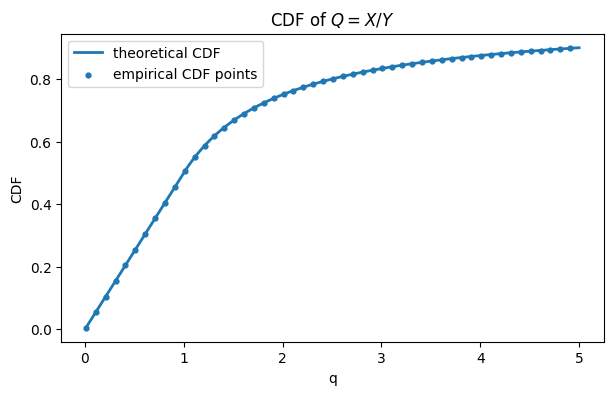

In [14]:
# Solution to Practice 6
N = 300_000
X = rng.uniform(0, 1, N)
Y = rng.uniform(0, 1, N)
Q = X/Y

def F_Q(q):
    q = np.asarray(q)
    return np.where(q <= 0, 0, np.where(q < 1, q/2, 1 - 1/(2*q)))

for q0 in [0.25, 0.5, 1.0, 2.0, 5.0]:
    empirical = np.mean(Q <= q0)
    theoretical = F_Q(q0)
    print(f"q={q0:>4}: empirical={empirical:.4f}, theoretical={theoretical:.4f}")

qs = np.linspace(0.01, 5, 500)
plt.figure(figsize=(7, 4))
plt.plot(qs, F_Q(qs), linewidth=2, label="theoretical CDF")
# empirical CDF sampled at qs
emp = np.array([np.mean(Q <= q) for q in qs[::10]])
plt.scatter(qs[::10], emp, s=12, label="empirical CDF points")
plt.xlabel("q")
plt.ylabel("CDF")
plt.title(r"CDF of $Q=X/Y$")
plt.legend()
plt.show()

**Solution.** On the unit square, $X/Y\le q$ means $X\le qY$.

For $0<q<1$, the line $x=qy$ stays below $1$, so the area is

$$
\int_0^1 qy\,dy=\frac q2.
$$

For $q\ge 1$, the line $x=qy$ crosses $x=1$ at $y=1/q$. Thus

$$
F_Q(q)=\int_0^{1/q} qy\,dy+\int_{1/q}^{1}1\,dy
=\frac{1}{2q}+1-\frac1q
=1-\frac{1}{2q}.
$$

## 8. Maximum and minimum transformations

Let $Y_1,\ldots,Y_n$ be iid with CDF $F$ and pdf $f$.

For the maximum $M=\max(Y_1,\ldots,Y_n)$,

$$
F_M(m)=P(M\le m)=F(m)^n,
$$

and

$$
f_M(m)=nF(m)^{n-1}f(m).
$$

For the minimum $L=\min(Y_1,\ldots,Y_n)$,

$$
P(L>\ell)=P(Y_1>\ell,\ldots,Y_n>\ell)=(1-F(\ell))^n,
$$

so

$$
F_L(\ell)=1-(1-F(\ell))^n.
$$

### Example 6
If $Y_i\sim U(0,1)$, then

$$
f_M(m)=nm^{n-1},\qquad 0<m<1.
$$

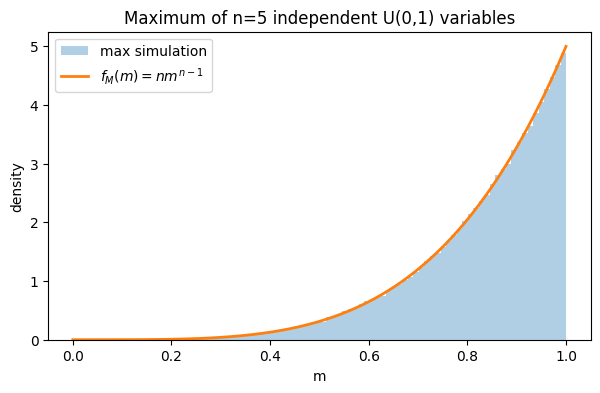

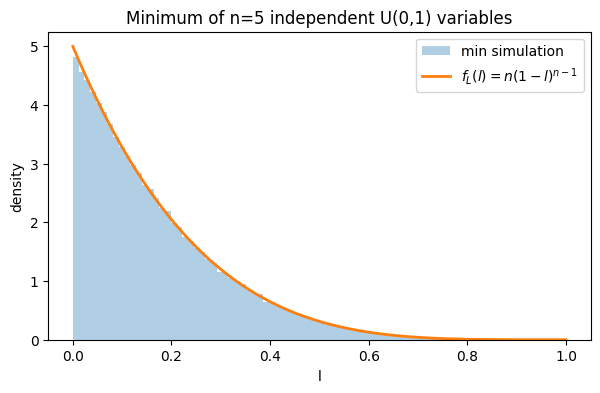

Empirical E[max]: 0.8330060018195223 Theoretical: 0.8333333333333334
Empirical E[min]: 0.16670217896444883 Theoretical: 0.16666666666666666


In [15]:
# Solution to Example 6: maximum of iid uniforms
n = 5
N = 200_000
samples = rng.uniform(0, 1, size=(N, n))
M = samples.max(axis=1)
L = samples.min(axis=1)

xs = np.linspace(0, 1, 500)
fM = n * xs**(n-1)
fL = n * (1-xs)**(n-1)

plt.figure(figsize=(7, 4))
plt.hist(M, bins=80, density=True, alpha=0.35, label="max simulation")
plt.plot(xs, fM, linewidth=2, label=r"$f_M(m)=n m^{n-1}$")
plt.xlabel("m")
plt.ylabel("density")
plt.title(f"Maximum of n={n} independent U(0,1) variables")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(L, bins=80, density=True, alpha=0.35, label="min simulation")
plt.plot(xs, fL, linewidth=2, label=r"$f_L(l)=n(1-l)^{n-1}$")
plt.xlabel("l")
plt.ylabel("density")
plt.title(f"Minimum of n={n} independent U(0,1) variables")
plt.legend()
plt.show()

print("Empirical E[max]:", M.mean(), "Theoretical:", n/(n+1))
print("Empirical E[min]:", L.mean(), "Theoretical:", 1/(n+1))

### Practice 7
Let $Y_1,\ldots,Y_n\sim \operatorname{Exponential}(\lambda)$ iid. Find the distribution of the minimum

$$
L=\min(Y_1,\ldots,Y_n).
$$

Verify by simulation for $n=4$ and $\lambda=2$.

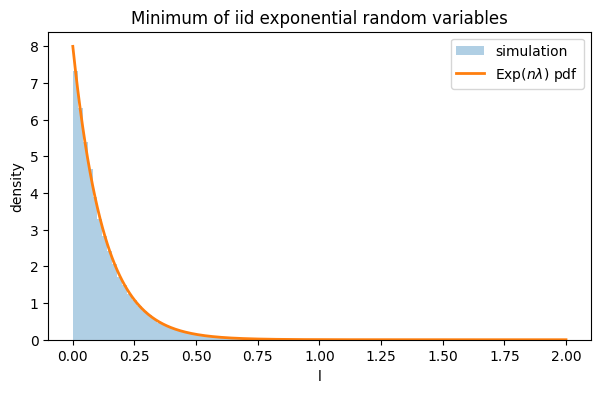

Empirical mean: 0.12480995753371937
Theoretical mean: 0.125


In [16]:
# Solution to Practice 7
n = 4
lam = 2
N = 200_000
Y = rng.exponential(scale=1/lam, size=(N, n))
L = Y.min(axis=1)

xs = np.linspace(0, 2, 400)
# Minimum of iid Exp(lambda) is Exp(n*lambda)
fL = n*lam*np.exp(-n*lam*xs)

plt.figure(figsize=(7, 4))
plt.hist(L, bins=100, density=True, alpha=0.35, range=(0, 2), label="simulation")
plt.plot(xs, fL, linewidth=2, label=r"Exp$(n\lambda)$ pdf")
plt.xlabel("l")
plt.ylabel("density")
plt.title(r"Minimum of iid exponential random variables")
plt.legend()
plt.show()

print("Empirical mean:", L.mean())
print("Theoretical mean:", 1/(n*lam))

**Solution.** For $\ell\ge 0$,

$$
P(L>\ell)=P(Y_1>\ell,\ldots,Y_n>\ell)
=\prod_{i=1}^n e^{-\lambda \ell}=e^{-n\lambda \ell}.
$$

Thus

$$
F_L(\ell)=1-e^{-n\lambda \ell},\qquad \ell\ge 0.
$$

So

$$
L\sim \operatorname{Exponential}(n\lambda).
$$

## 9. Full mixed practice: transformations and simulation

This final problem combines a CDF method, inverse images, and simulation.

### Practice 8
Let $X\sim U(0,1)$ and define

$$
Y=-\log X.
$$

1. Find the distribution of $Y$.
2. Simulate $Y$ and compare with the theoretical pdf.
3. Compute $P(Y>2)$ theoretically and empirically.

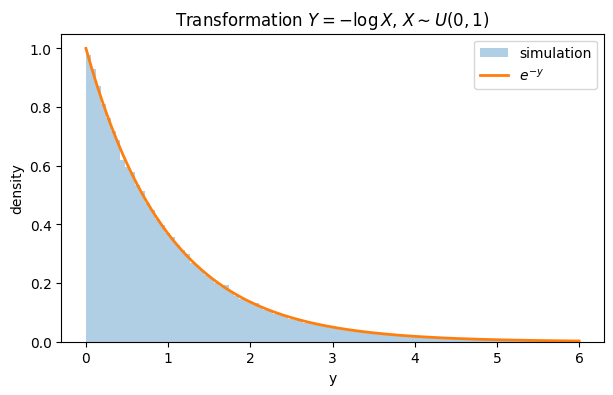

Empirical P(Y>2): 0.134285
Theoretical P(Y>2): 0.1353352832366127


In [17]:
# Solution to Practice 8
N = 200_000
X = rng.uniform(0, 1, N)
Y = -np.log(X)

ys = np.linspace(0, 6, 500)
fY = np.exp(-ys)

plt.figure(figsize=(7, 4))
plt.hist(Y, bins=100, density=True, alpha=0.35, range=(0, 6), label="simulation")
plt.plot(ys, fY, linewidth=2, label=r"$e^{-y}$")
plt.xlabel("y")
plt.ylabel("density")
plt.title(r"Transformation $Y=-\log X$, $X\sim U(0,1)$")
plt.legend()
plt.show()

empirical_tail = np.mean(Y > 2)
theoretical_tail = np.exp(-2)
print("Empirical P(Y>2):", empirical_tail)
print("Theoretical P(Y>2):", theoretical_tail)

**Solution.** Since $Y=-\log X$, the support is $Y>0$. For $y\ge 0$,

$$
F_Y(y)=P(Y\le y)=P(-\log X\le y).
$$

This is equivalent to

$$
\log X\ge -y,
$$

so

$$
X\ge e^{-y}.
$$

Since $X\sim U(0,1)$,

$$
F_Y(y)=P(X\ge e^{-y})=1-e^{-y},\qquad y\ge 0.
$$

Therefore

$$
f_Y(y)=e^{-y},\qquad y>0.
$$

Hence $Y\sim \operatorname{Exponential}(1)$ and

$$
P(Y>2)=e^{-2}.
$$

## Lab summary

In this lab, we used Python to verify and explore the main ideas of Section 5:

- Discrete transformations require summing over inverse images.
- The CDF method is often the most reliable method for continuous transformations.
- The monotone transformation formula uses the derivative of the inverse function.
- Non-monotone transformations require summing over all inverse branches.
- Inverse-transform sampling turns uniform random variables into random variables from a chosen distribution.
- Jacobians are required for transformations of multiple continuous random variables.
- Convolutions, products, quotients, maxima, and minima are all transformation problems.

These tools will appear repeatedly in later topics: sampling distributions, order statistics, Monte Carlo methods, likelihood calculations, and statistical inference.